In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data,
     data.target.rename("HousePrice")],
    axis=1
)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [14]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([name, rmse, r2])


In [16]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745554  0.575819
2      Decision Tree  0.724234  0.599732


In [18]:
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nBest Model:")
print(best_model.head(1))


Best Model:
           Model      RMSE  R2 Score
2  Decision Tree  0.724234  0.599732


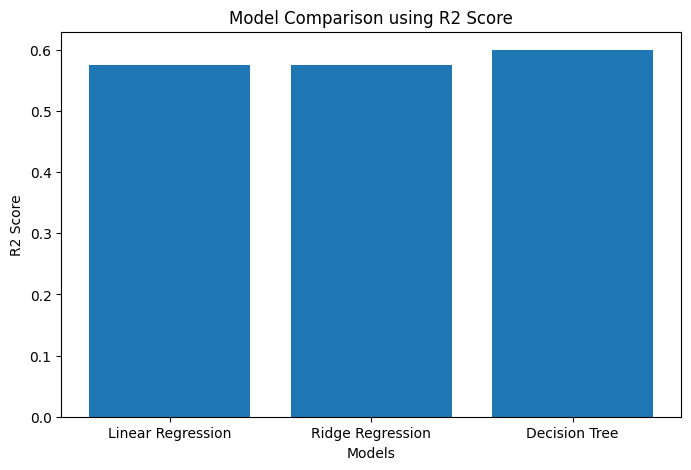

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Model Comparison using R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

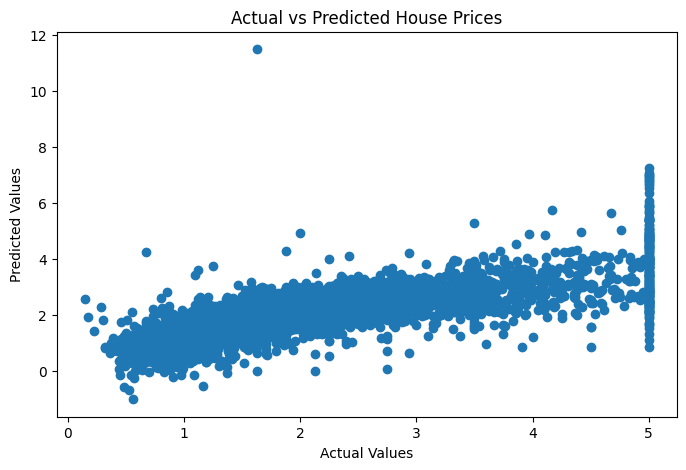

In [21]:
final_model = LinearRegression()

final_model.fit(X_train, y_train)

pred = final_model.predict(X_test)

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

plt.show()